In [61]:
import pandas as pd
import numpy as np
from src.loader.reader import Dataset_BigEarthNet, Reader

## Evaluate the Imbalanced classes at the parquet df

In [4]:
df_parquet = pd.read_parquet('/root/storage_ds/metadata.parquet')

In [3]:
## For all samples

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

df_sum = pd.DataFrame()
smal_df_sum['labels'] = labels_df.columns.values
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
weights = np.clip(df_sum['neg/pos'].values,1,100)

In [45]:
df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,33181,2.343528,1382676,41.670715
1,Arable land,188025,13.279943,1227832,6.530153
2,"Beaches, dunes, sands",1316,0.092947,1414541,1074.879179
3,Broad-leaved forest,135928,9.600405,1279929,9.416228
4,Coastal wetlands,1397,0.098668,1414460,1012.498210
5,Complex cultivation patterns,99598,7.034467,1316259,13.215717
6,Coniferous forest,154941,10.943266,1260916,8.138040
7,Industrial or commercial units,11142,0.786944,1404715,126.073865
8,Inland waters,63212,4.464575,1352645,21.398548
9,Inland wetlands,20919,1.477480,1394938,66.682824


<Axes: xlabel='labels'>

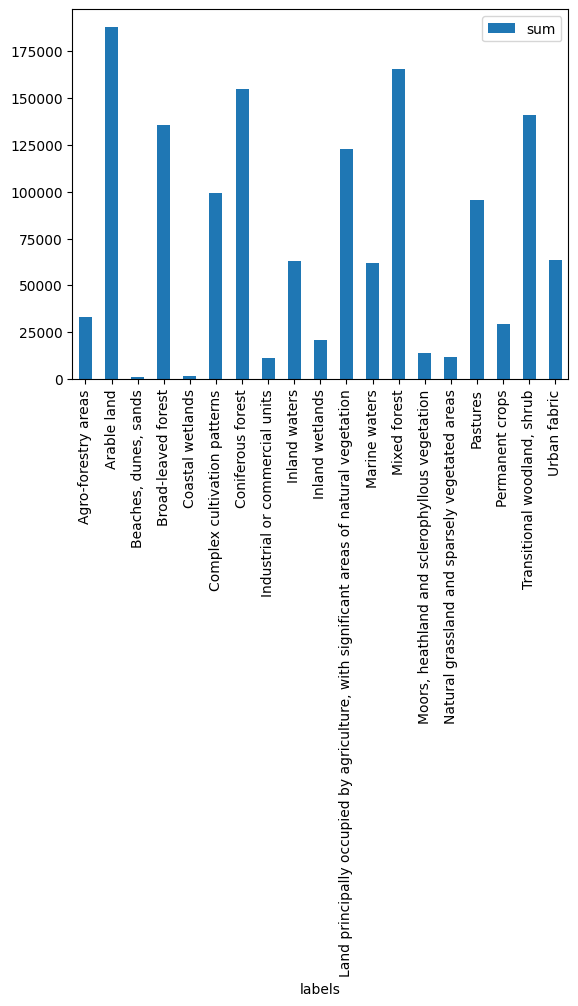

In [ ]:
df_sum.set_index('labels')[['percent']].plot(kind='bar')

## Training

In [86]:
## For training

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'].loc[df_parquet['split']=='train'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

train_df_sum = pd.DataFrame()
train_df_sum['labels'] = labels_df.columns.values
train_df_sum['sum'] = labels_df.sum(0).values
train_df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
train_df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
train_df_sum['neg/pos'] = train_df_sum['num_negatives']/train_df_sum['sum']
weights = np.clip(train_df_sum['neg/pos'].values,1,100)

In [60]:
df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,15082,2.190232,673521,44.657274
1,Arable land,88236,12.813769,600367,6.804105
2,"Beaches, dunes, sands",738,0.107174,687865,932.066396
3,Broad-leaved forest,64164,9.317996,624439,9.731921
4,Coastal wetlands,670,0.097298,687933,1026.765672
5,Complex cultivation patterns,51034,7.411237,637569,12.493024
6,Coniferous forest,76344,11.086795,612259,8.019740
7,Industrial or commercial units,6398,0.929128,682205,106.627852
8,Inland waters,30466,4.424320,658137,21.602344
9,Inland wetlands,11344,1.647393,677259,59.701957


<Axes: xlabel='labels'>

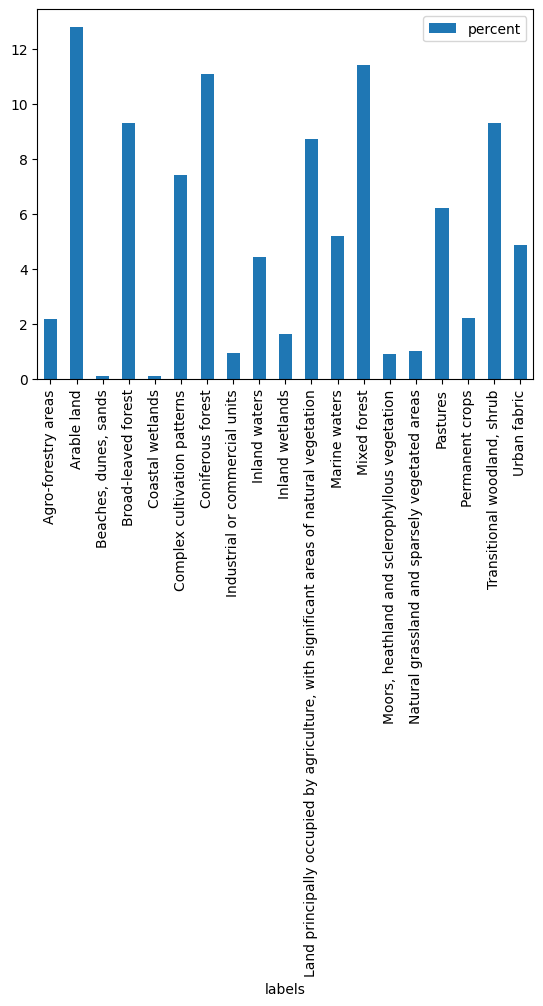

In [ ]:
train_df_sum.set_index('labels')[['percent']].plot(kind='bar')

## Validation

In [57]:

mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(df_parquet['labels'].loc[df_parquet['split']=='validation'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

df_sum = pd.DataFrame()
df_sum['labels'] = labels_df.columns.values
df_sum['sum'] = labels_df.sum(0).values
df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
df_sum['neg/pos'] = df_sum['num_negatives']/df_sum['sum']
weights = np.clip(df_sum['neg/pos'].values,1,100)

In [58]:
df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,8157,2.214308,360220,44.160843
1,Arable land,49737,13.501657,318640,6.406498
2,"Beaches, dunes, sands",426,0.115642,367951,863.734742
3,Broad-leaved forest,35387,9.606191,332990,9.409953
4,Coastal wetlands,610,0.165591,367767,602.896721
5,Complex cultivation patterns,26486,7.189917,341891,12.908367
6,Coniferous forest,39554,10.737370,328823,8.313268
7,Industrial or commercial units,2726,0.740003,365651,134.134629
8,Inland waters,15900,4.316230,352477,22.168365
9,Inland wetlands,5056,1.372507,363321,71.859375


<Axes: xlabel='labels'>

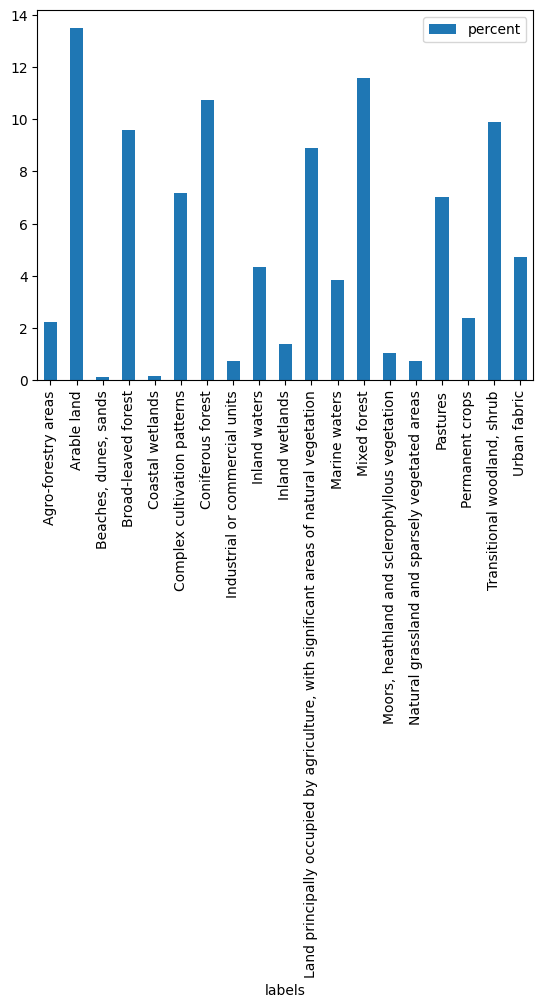

In [48]:
df_sum.set_index('labels')[['percent']].plot(kind='bar')

## Train with partial dataset 

20% of the train dataset

In [62]:
label_to_idx = {
    'Arable land': 0,
    'Broad-leaved forest': 1,
    'Mixed forest': 2,
    'Pastures': 3,
    'Inland waters': 4,
    'Coniferous forest': 5,
    'Complex cultivation patterns': 6,
    'Land principally occupied by agriculture, with significant areas of natural vegetation': 7,
    'Urban fabric': 8,
    'Industrial or commercial units': 9,
    'Inland wetlands': 10,
    'Transitional woodland, shrub': 11,
    'Natural grassland and sparsely vegetated areas': 12,
    'Moors, heathland and sclerophyllous vegetation': 13,
    'Marine waters': 14,
    'Coastal wetlands': 15,
    'Permanent crops': 16,
    'Beaches, dunes, sands': 17,
    'Agro-forestry areas': 18
}

In [64]:

reader = Reader("~/storage_ds/BigEarthNet-S2", "/root/storage_ds/metadata.parquet")

datasetmod = Dataset_BigEarthNet(
    reader= reader,
    strip_bands = ["B02", "B03", "B04"],
    img_size= 120,
    upsample_mode='nearest',
    normalize =True,
    split_train_test= 'train',
    dict_one_hot=label_to_idx,
    small_fraction=0.25
)

2025-08-14 11:36:37.910 | INFO     | src.loader.reader:__init__:208 - Initializing the Reader, structuring the paths and files.
2025-08-14 11:36:38.400 | INFO     | src.loader.reader:parent_folders:260 - Found 115 folders in /root/storage_ds/BigEarthNet-S2
2025-08-14 11:36:44.330 | INFO     | src.loader.reader:_create_lookup_structures:244 - Created lookup structures for 480038 patches
2025-08-14 11:36:44.331 | INFO     | src.loader.reader:__init__:228 - None
2025-08-14 11:36:44.443 | INFO     | src.loader.reader:__init__:451 - train split, with length of 237871
2025-08-14 11:36:44.444 | WARNING  | src.loader.reader:__init__:459 - Small sample selected. Dataset is reduced!
2025-08-14 11:36:44.444 | INFO     | src.loader.reader:__init__:460 - train split, with length of 59467
2025-08-14 11:36:44.444 | INFO     | src.loader.reader:__init__:469 - Bands orded by: ['B02', 'B03', 'B04']


Number of parent folders: 115
Number of total patches found it: 549488


In [68]:
len(datasetmod.patch_ids_array)

59467

In [75]:
short_train = df_parquet.loc[df_parquet["patch_id"].isin(datasetmod.patch_ids_array)]

In [81]:
mlb = MultiLabelBinarizer()
labels_matrix = mlb.fit_transform(short_train['labels'])

# Convert to DataFrame for easy use
labels_df = pd.DataFrame(labels_matrix, columns=mlb.classes_)
labels_df.head()

smal_df_sum = pd.DataFrame()
smal_df_sum['labels'] = labels_df.columns.values
smal_df_sum['sum'] = labels_df.sum(0).values
smal_df_sum['percent'] = (labels_df.sum(0).values/labels_df.sum(0).values.sum())*100
smal_df_sum['num_negatives'] = (labels_df.T.sum(1).sum()- labels_df.T.sum(1)).values
smal_df_sum['neg/pos'] = smal_df_sum['num_negatives']/smal_df_sum['sum']
weights = np.clip(smal_df_sum['neg/pos'].values,1,100)

In [82]:
smal_df_sum

,labels,sum,percent,num_negatives,neg/pos
0,Agro-forestry areas,7966,4.892670,154849,19.438740
1,Arable land,22470,13.800940,140345,6.245883
2,"Beaches, dunes, sands",306,0.187943,162509,531.075163
3,Broad-leaved forest,11926,7.324878,150889,12.652105
4,Coastal wetlands,309,0.189786,162506,525.909385
5,Complex cultivation patterns,8588,5.274698,154227,17.958430
6,Coniferous forest,17306,10.629242,145509,8.408009
7,Industrial or commercial units,1740,1.068698,161075,92.571839
8,Inland waters,8079,4.962074,154736,19.152865
9,Inland wetlands,2422,1.487578,160393,66.223369


/tmp/ipykernel_3748159/2802410548.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


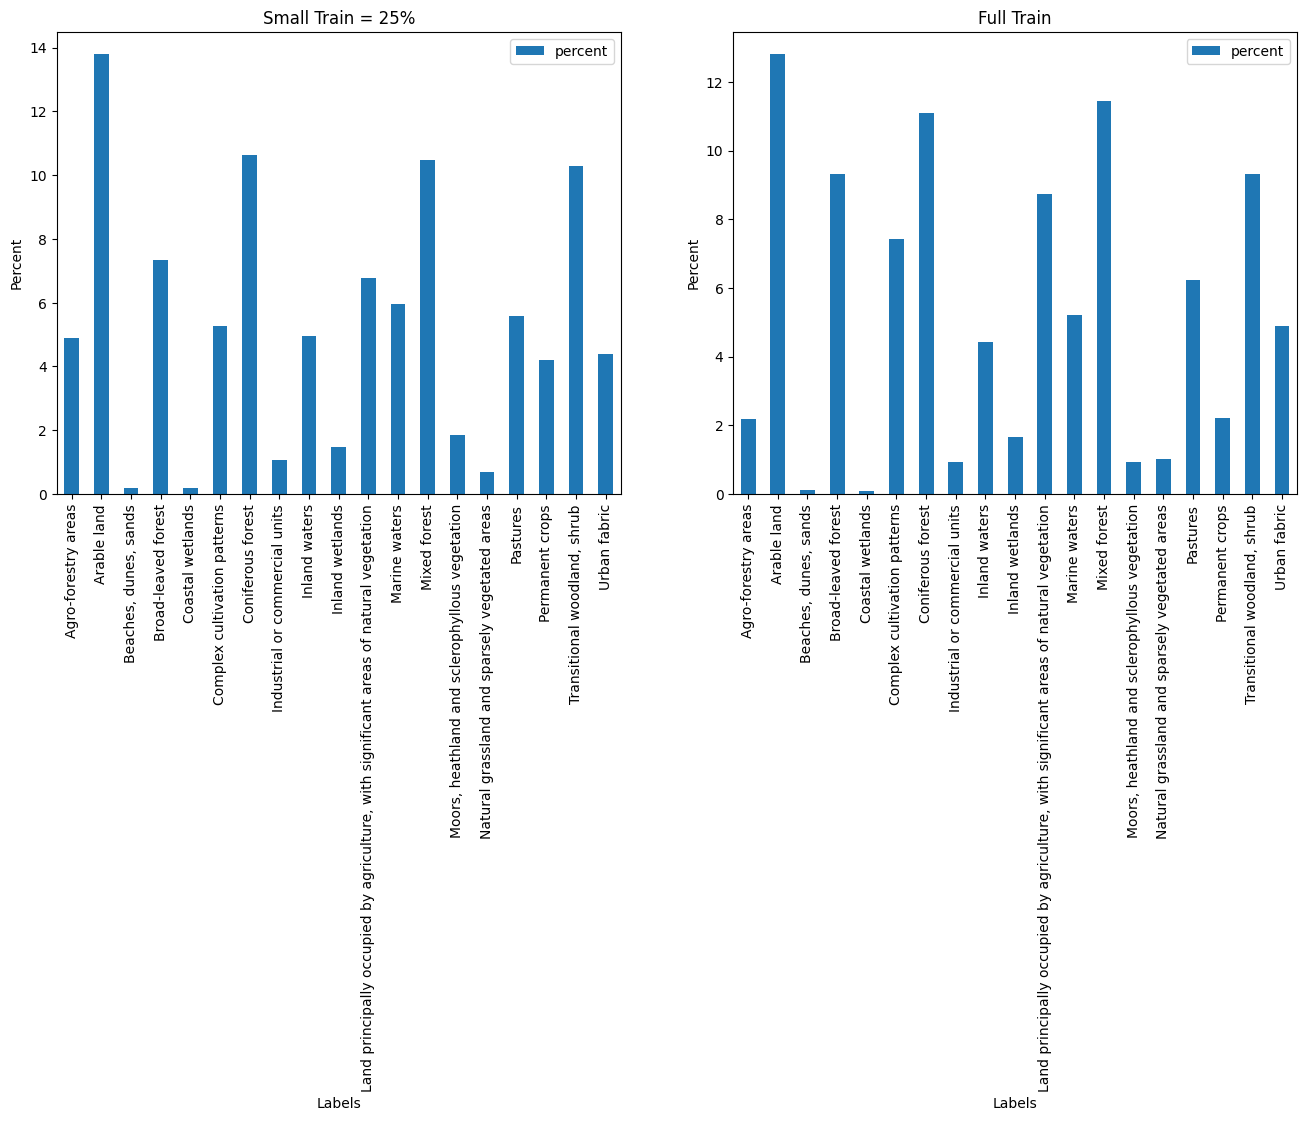

In [87]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

smal_df_sum.set_index('labels')[['percent']].plot(kind='bar', ax=axs[0], title='Small Train = 25%')
train_df_sum.set_index('labels')[['percent']].plot(kind='bar', ax=axs[1], title='Full Train')

axs[0].set_ylabel('Percent')
axs[1].set_ylabel('Percent')
axs[0].set_xlabel('Labels')
axs[1].set_xlabel('Labels')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3748159/1795829468.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


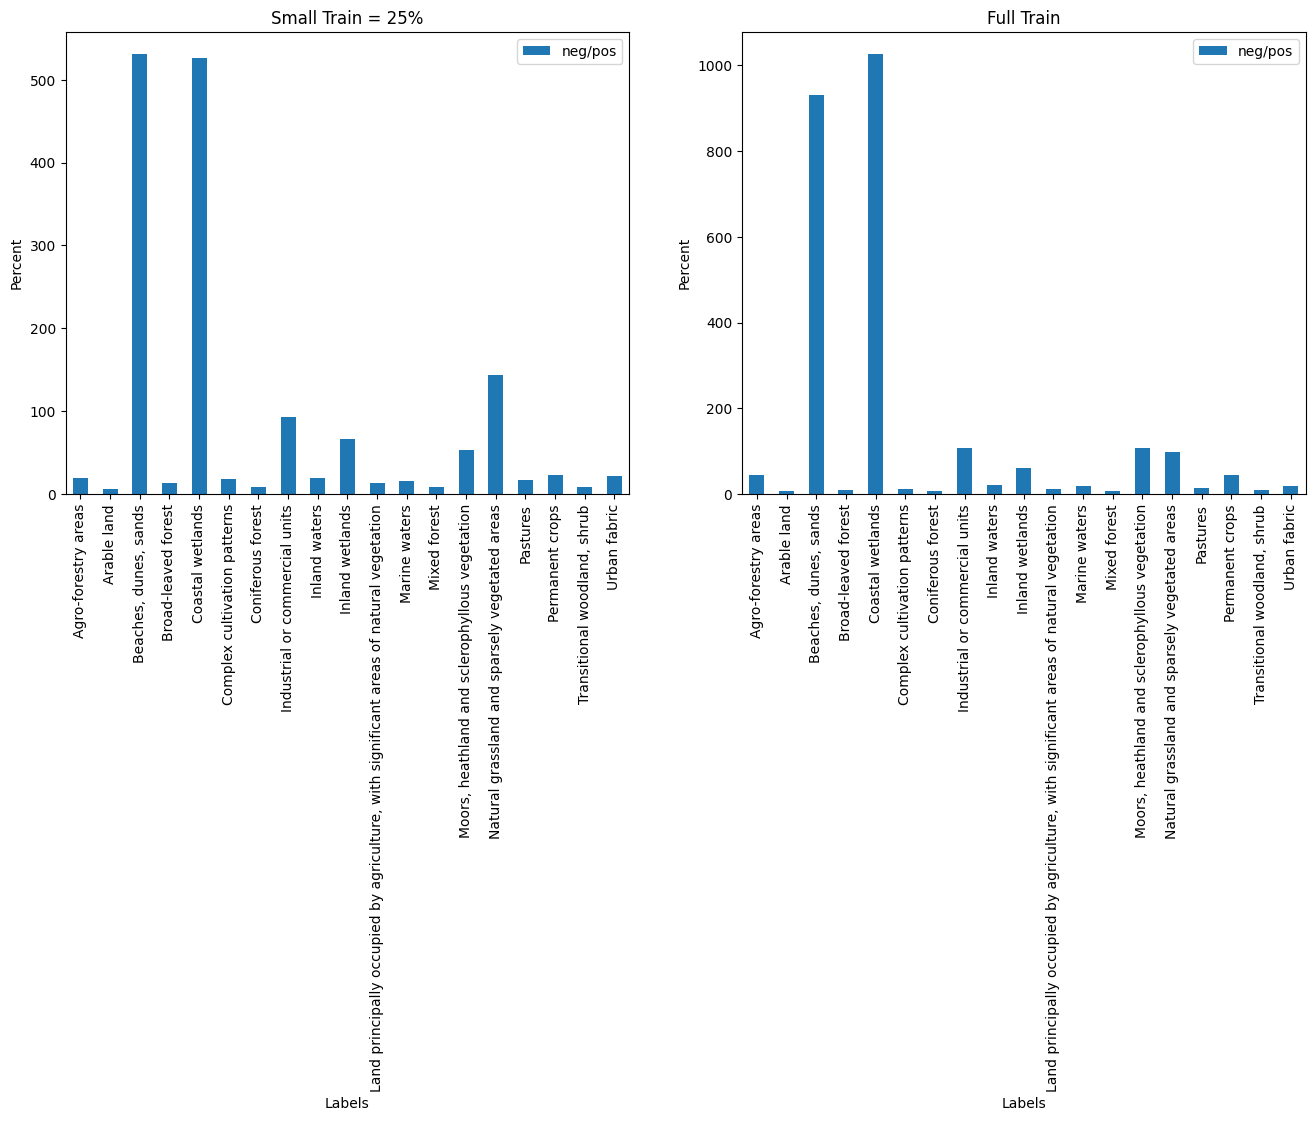

In [88]:
## Comparing Weights

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

smal_df_sum.set_index('labels')[['neg/pos']].plot(kind='bar', ax=axs[0], title='Small Train = 25%')
train_df_sum.set_index('labels')[['neg/pos']].plot(kind='bar', ax=axs[1], title='Full Train')

axs[0].set_ylabel('Percent')
axs[1].set_ylabel('Percent')
axs[0].set_xlabel('Labels')
axs[1].set_xlabel('Labels')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3748159/3778179578.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


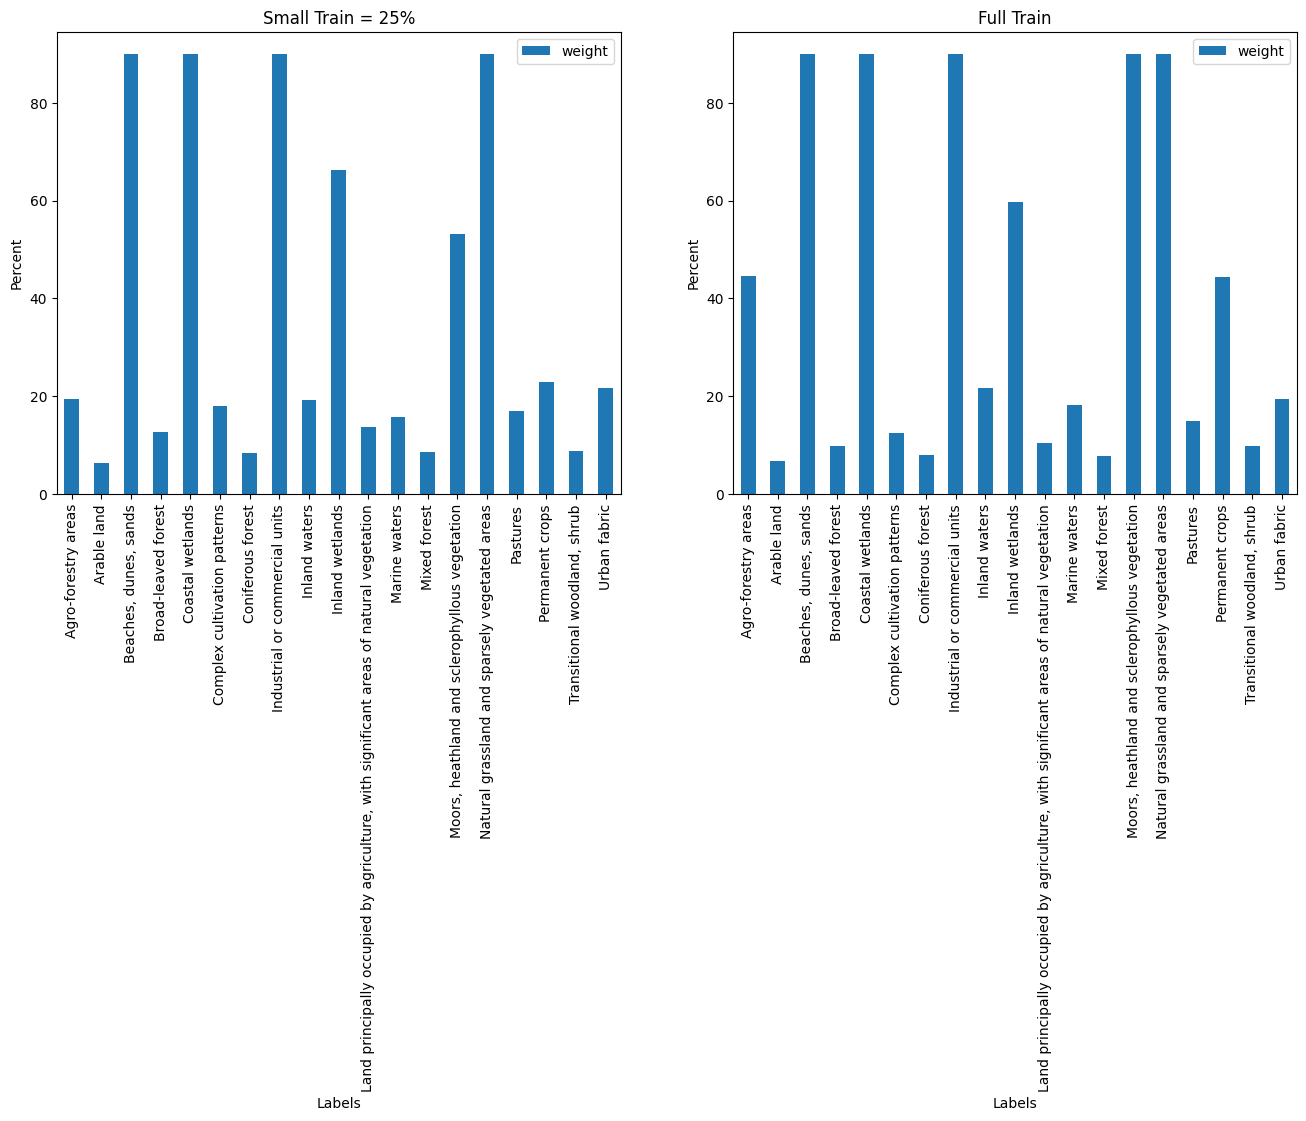

In [91]:
import matplotlib.pyplot as plt

smal_df_sum['weight'] = np.clip(smal_df_sum['neg/pos'].values,1,90)
train_df_sum['weight'] = np.clip(train_df_sum['neg/pos'].values,1,90)

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

smal_df_sum.set_index('labels')[['weight']].plot(kind='bar', ax=axs[0], title='Small Train = 25%')
train_df_sum.set_index('labels')[['weight']].plot(kind='bar', ax=axs[1], title='Full Train')

axs[0].set_ylabel('Percent')
axs[1].set_ylabel('Percent')
axs[0].set_xlabel('Labels')
axs[1].set_xlabel('Labels')

plt.tight_layout()
plt.show()

## Comparing Weights

import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

smal_df_sum.set_index('labels')[['neg/pos']].plot(kind='bar', ax=axs[0], title='Small Train = 25%')
train_df_sum.set_index('labels')[['neg/pos']].plot(kind='bar', ax=axs[1], title='Full Train')

axs[0].set_ylabel('Percent')
axs[1].set_ylabel('Percent')
axs[0].set_xlabel('Labels')
axs[1].set_xlabel('Labels')

plt.tight_layout()
plt.show()